In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
customer = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category = pd.read_csv('product_category_name_translation.csv')

In [ ]:
print(orders.shape)
print(orders.dtypes)
print(orders.isnull().sum())
orders.head(3)

In [4]:
print(items.shape)
print(items.dtypes)
print(items.isnull().sum())
items.head(3)

(112650, 7)
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [5]:
print(customer.shape)
print(customer.dtypes)
print(customer.isnull().sum())
customer.head(3)

(99441, 5)
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [6]:
items[items['order_id'] == items['order_id'].value_counts().index[0]]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
57297,8272b63d03f5f79c56e9e4120aec44ef,1,270516a3f41dc035aa87d220228f844c,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57298,8272b63d03f5f79c56e9e4120aec44ef,2,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57299,8272b63d03f5f79c56e9e4120aec44ef,3,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57300,8272b63d03f5f79c56e9e4120aec44ef,4,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57301,8272b63d03f5f79c56e9e4120aec44ef,5,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57302,8272b63d03f5f79c56e9e4120aec44ef,6,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57303,8272b63d03f5f79c56e9e4120aec44ef,7,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57304,8272b63d03f5f79c56e9e4120aec44ef,8,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57305,8272b63d03f5f79c56e9e4120aec44ef,9,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57306,8272b63d03f5f79c56e9e4120aec44ef,10,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89


In [7]:
items[items['order_id'] == items['order_id'].value_counts().index[0]][['price', 'freight_value', 'product_id']]

,price,freight_value,product_id
57297,1.2,7.89,270516a3f41dc035aa87d220228f844c
57298,1.2,7.89,05b515fdc76e888aada3c6d66c201dff
57299,1.2,7.89,05b515fdc76e888aada3c6d66c201dff
57300,1.2,7.89,05b515fdc76e888aada3c6d66c201dff
57301,1.2,7.89,05b515fdc76e888aada3c6d66c201dff
57302,1.2,7.89,05b515fdc76e888aada3c6d66c201dff
57303,1.2,7.89,05b515fdc76e888aada3c6d66c201dff
57304,1.2,7.89,05b515fdc76e888aada3c6d66c201dff
57305,1.2,7.89,05b515fdc76e888aada3c6d66c201dff
57306,1.2,7.89,05b515fdc76e888aada3c6d66c201dff


In [8]:
items.groupby('order_id').size().describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

FINDING 1

75% of customers have ordered single item compared to multi-basket items found on other platforms. As logistic cost is fixed this is compressing the revenue but to know the full impact we will need a logistic data but from this analysis we can clearly state that encoraging multi-basket behaviour will affect the revenue. A loyalty incentive for orders exceeding 2 items — such as a discount on freight or reward points — could nudge single-item buyers toward larger baskets

In [9]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_purchase_timestamp']

0       2017-10-02 10:56:33
1       2018-07-24 20:41:37
2       2018-08-08 08:38:49
3       2017-11-18 19:28:06
4       2018-02-13 21:18:39
                ...        
99436   2017-03-09 09:54:05
99437   2018-02-06 12:58:58
99438   2017-08-27 14:46:43
99439   2018-01-08 21:28:27
99440   2018-03-08 20:57:30
Name: order_purchase_timestamp, Length: 99441, dtype: datetime64[ns]

In [10]:
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['year']

0        2017
1        2018
2        2018
3        2017
4        2018
         ... 
99436    2017
99437    2018
99438    2017
99439    2018
99440    2018
Name: year, Length: 99441, dtype: int32

In [11]:
orders['month'] = orders['order_purchase_timestamp'].dt.month
orders['month']

0        10
1         7
2         8
3        11
4         2
         ..
99436     3
99437     2
99438     8
99439     1
99440     3
Name: month, Length: 99441, dtype: int32

In [12]:
result = pd.merge(items,orders,on='order_id',how='inner')
result

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,2017,9
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,2017,4
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,2018,1
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,2018,8
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,2017,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18 00:00:00,2018,4
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01 00:00:00,2018,7
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10 00:00:00,2017,10
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25 00:00:00,2017,8


In [13]:
monthly_revenue = result.groupby(['year','month'])['price'].sum()
monthly_revenue

year  month
2016  9            267.36
      10         49507.66
      12            10.90
2017  1         120312.87
      2         247303.02
      3         374344.30
      4         359927.23
      5         506071.14
      6         433038.60
      7         498031.48
      8         573971.68
      9         624401.69
      10        664219.43
      11       1010271.37
      12        743914.17
2018  1         950030.36
      2         844178.71
      3         983213.44
      4         996647.75
      5         996517.68
      6         865124.31
      7         895507.22
      8         854686.33
      9            145.00
Name: price, dtype: float64

In [14]:
orders[(orders['year']==2018)& (orders['month']==9)].shape[0]

16

In [15]:
orders[(orders['year']==2018)& (orders['month']==8)].shape[0]

6512

FINDING 2

The dataset contains only 16 orders in September 2018 compared to 6,512 in August 2018, indicating a data cutoff. September 2018 will be excluded from all trend analysis to avoid distorted conclusions.

In [16]:
monthly_orders = orders.groupby(['year','month'])['order_id'].count()
monthly_orders

year  month
2016  9           4
      10        324
      12          1
2017  1         800
      2        1780
      3        2682
      4        2404
      5        3700
      6        3245
      7        4026
      8        4331
      9        4285
      10       4631
      11       7544
      12       5673
2018  1        7269
      2        6728
      3        7211
      4        6939
      5        6873
      6        6167
      7        6292
      8        6512
      9          16
      10          4
Name: order_id, dtype: int64

In [17]:
result.groupby(['year','month'])['seller_id'].nunique()

year  month
2016  9           3
      10        143
      12          1
2017  1         227
      2         427
      3         499
      4         506
      5         583
      6         539
      7         606
      8         708
      9         731
      10        776
      11        965
      12        861
2018  1         970
      2         947
      3         996
      4        1123
      5        1115
      6        1175
      7        1261
      8        1278
      9           1
Name: seller_id, dtype: int64

FINDING 3

Olist has a near-zero customer retention rate — almost every customer orders exactly once and never returns. This means Olist's entire revenue depends on continuously acquiring new customers. The moment new customer acquisition slows down, revenue drops immediately — which is exactly what the June 2018 decline shows.

In [18]:
reviews.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


In [19]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [20]:
products['product_category_name'].nunique()

73

In [21]:
translation = pd.merge(products,category,on='product_category_name',how='inner')
translation

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares
...,...,...,...,...,...,...,...,...,...,...
32323,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0,furniture_decor
32324,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0,construction_tools_lights
32325,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,bed_bath_table
32326,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0,computers_accessories


In [22]:
translation[['product_category_name','product_category_name_english']]

,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
...,...,...
32323,moveis_decoracao,furniture_decor
32324,construcao_ferramentas_iluminacao,construction_tools_lights
32325,cama_mesa_banho,bed_bath_table
32326,informatica_acessorios,computers_accessories


In [23]:
result = pd.merge(result,translation,on='product_id',how='inner')
result

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,month,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,9,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,4,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,1,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,8,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111018,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,4,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,housewares
111019,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,7,informatica_acessorios,31.0,232.0,1.0,8950.0,45.0,26.0,38.0,computers_accessories
111020,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,10,esporte_lazer,43.0,869.0,1.0,967.0,21.0,24.0,19.0,sports_leisure
111021,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,8,informatica_acessorios,56.0,1306.0,1.0,100.0,20.0,20.0,20.0,computers_accessories


In [26]:
result.groupby('product_category_name_english')['order_id'].count().nlargest(10)

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: order_id, dtype: int64

FINDING 4

The top categories — health & beauty, bed & bath, sports & leisure — are all replenishable products that customers typically repurchase. The near-zero retention rate cannot be explained by product type, pointing instead to a fundamental gap in Olist's customer retention strategy — no loyalty program, no re-engagement campaigns, no personalized recommendations.

In [ ]:
reviews.columns

In [ ]:
reviews['review_score'].mean()

In [ ]:
reviews['review_score'].value_counts()

In [ ]:
reviews[(reviews['review_score'] == 1) | (reviews['review_score'] == 2)].shape[0]/reviews.shape[0]*100

FINDING 5

Olist's retention problem is not primarily driven by bad experience — 85% of customers rate their experience 3 stars or above. The problem is that even satisfied customers don't return, suggesting Olist has no re-engagement mechanism — no email reminders, no loyalty program, no personalized recommendations to bring happy customers back.

In [65]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')

In [64]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date            object
order_estimated_delivery_date            object
year                                      int32
month                                     int32
dtype: object

In [66]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [67]:
delivered_order = orders[orders['order_status'] == 'delivered'].copy()
delivered_order

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2
...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,2017,3
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,2018,2
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,2017,8
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018,1


In [73]:
delivered_order = orders[orders['order_status'] == 'delivered'].copy()

In [72]:
delivered_order['order_delivered_customer_date'].isna().sum()

np.int64(8)

In [70]:
orders[orders['order_status'] == 'delivered']['order_delivered_customer_date'].isna().sum()

np.int64(8)

In [71]:
orders['order_delivered_customer_date'].isna().sum()

np.int64(2965)

In [74]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
print(orders['order_delivered_customer_date'].dtype)
print(orders['order_delivered_customer_date'].isna().sum())

datetime64[ns]
2965


In [75]:
pd.read_csv('olist_orders_dataset.csv')['order_delivered_customer_date'].head(10)

0    2017-10-10 21:25:13
1    2018-08-07 15:27:45
2    2018-08-17 18:06:29
3    2017-12-02 00:28:42
4    2018-02-16 18:17:02
5    2017-07-26 10:57:55
6                    NaN
7    2017-05-26 12:55:51
8    2017-02-02 14:08:10
9    2017-08-16 17:14:30
Name: order_delivered_customer_date, dtype: object

In [76]:
orders = pd.read_csv('olist_orders_dataset.csv')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month

In [77]:
orders['order_delivered_customer_date'].isna().sum()

np.int64(2965)

In [78]:
delivered_order = orders[orders['order_status'] == 'delivered'].copy()
delivered_order['delivery_delay'] = delivered_order['order_delivered_customer_date'] - delivered_order['order_estimated_delivery_date']

In [79]:
delivered_order['delivery_delay'].isna().sum()

np.int64(8)

In [80]:
delivered_order[delivered_order['delivery_delay'] >pd.Timedelta(0)].shape[0]/delivered_order.shape[0]*100

8.111693857667031

In [81]:
delivery_review_score = pd.merge(delivered_order,reviews,on='order_id',how='inner')
delivery_review_score

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,delivery_delay,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,-8 days +21:25:13,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,-6 days +15:27:45,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,-18 days +18:06:29,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,-13 days +00:28:42,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,-10 days +18:17:02,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96356,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,2017,3,-11 days +15:08:01,e262b3f92d1ce917aa412a9406cf61a6,5,NaN,NaN,2017-03-22 00:00:00,2017-03-23 11:02:08
96357,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,2018,2,-2 days +17:37:56,29bb71b2760d0f876dfa178a76bc4734,4,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01
96358,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,2017,8,-6 days +11:24:17,371579771219f6db2d830d50805977bb,5,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57
96359,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018,1,-21 days +23:32:54,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56


In [82]:
delivery_review_score['is_late'] = delivery_review_score['delivery_delay'] > pd.Timedelta(0)
delivery_review_score['is_late']

0        False
1        False
2        False
3        False
4        False
         ...  
96356    False
96357    False
96358    False
96359    False
96360    False
Name: is_late, Length: 96361, dtype: bool

In [83]:
delivery_review_score.groupby('is_late')['review_score'].mean()

is_late
False    4.293737
True     2.566494
Name: review_score, dtype: float64

FINDING 6

Orders delivered late receive an average review score of 2.57 compared to 4.29 for on-time deliveries — a 40% drop in customer satisfaction. While only 8.1% of orders are late, these customers are highly likely driving the 14.7% negative review rate and are almost certainly never returning. Improving logistics reliability is the highest-impact operational fix Olist can make.

In [ ]:
result.groupby('product_category_name_english_x')['price'].sum().nlargest(10)

FINDING 7

Health & beauty is Olist's highest revenue category at R$1.25M despite being second in order volume, indicating higher average order values. Watches & gifts ranks second in revenue but much lower in order count — suggesting premium pricing. These high-value categories should be prioritised for seller acquisition and marketing investment.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
monthly_revenue = monthly_revenue.reset_index()
monthly_revenue

,year,month,price
0,2016,9,267.36
1,2016,10,49507.66
2,2016,12,10.90
3,2017,1,120312.87
4,2017,2,247303.02
5,2017,3,374344.30
6,2017,4,359927.23
7,2017,5,506071.14
8,2017,6,433038.60
9,2017,7,498031.48


In [29]:
monthly_revenue

,year,month,price,date
0,2016,9,267.36,2016-09-01
1,2016,10,49507.66,2016-10-01
2,2016,12,10.90,2016-12-01
3,2017,1,120312.87,2017-01-01
4,2017,2,247303.02,2017-02-01
5,2017,3,374344.30,2017-03-01
6,2017,4,359927.23,2017-04-01
7,2017,5,506071.14,2017-05-01
8,2017,6,433038.60,2017-06-01
9,2017,7,498031.48,2017-07-01


In [38]:
type(monthly_revenue)

pandas.core.series.Series

In [39]:
monthly_revenue = result.groupby(['year','month'])['price'].sum().reset_index()
monthly_revenue['date'] = pd.to_datetime(monthly_revenue[['year','month']].assign(day=1))
monthly_revenue = monthly_revenue[~((monthly_revenue['year'] == 2018) & (monthly_revenue['month'] == 9))]
monthly_revenue

,year,month,price,date
0,2016,9,267.36,2016-09-01
1,2016,10,49441.77,2016-10-01
2,2016,12,10.90,2016-12-01
3,2017,1,118610.23,2017-01-01
4,2017,2,238268.92,2017-02-01
5,2017,3,367630.13,2017-03-01
6,2017,4,350974.16,2017-04-01
7,2017,5,494979.21,2017-05-01
8,2017,6,427380.82,2017-06-01
9,2017,7,494906.82,2017-07-01


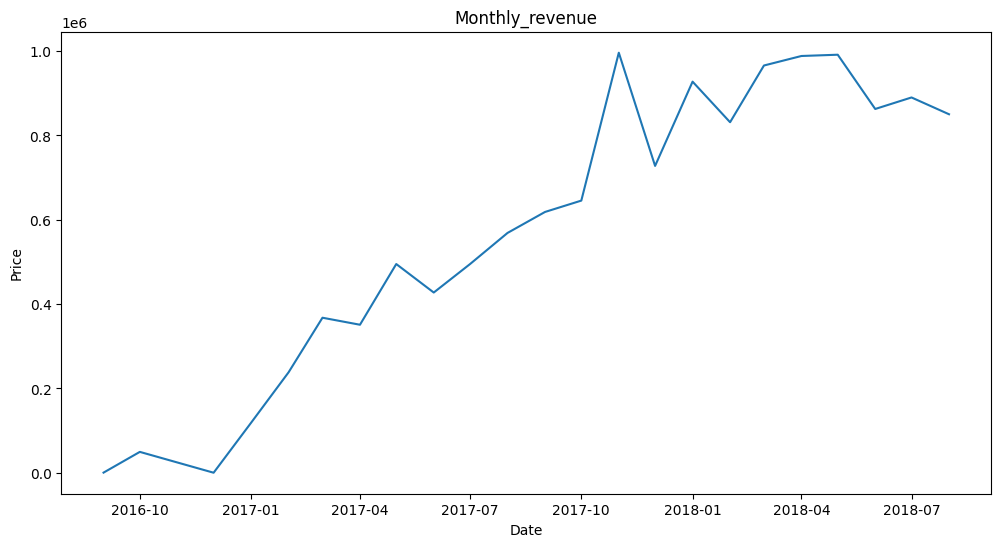

In [104]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['date'],monthly_revenue['price'])
plt.title('Monthly_revenue')
plt.xlabel('Date')
plt.ylabel('Price')
plt.savefig('monthly_revenue.png', bbox_inches='tight', dpi=150)
plt.show()

In [61]:
score_dist = reviews['review_score'].value_counts()

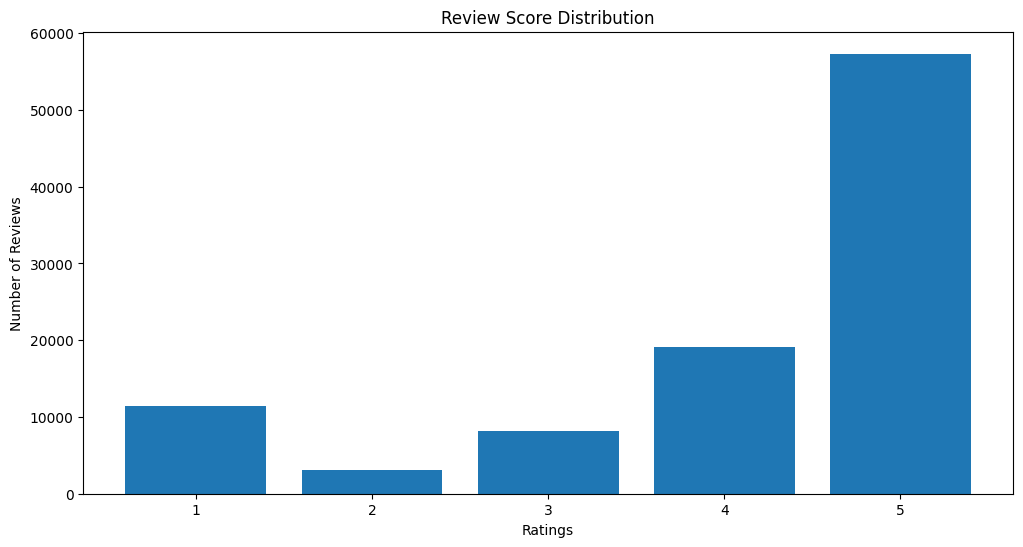

In [105]:
plt.figure(figsize=(12,6))
plt.bar(score_dist.index,score_dist.values)
plt.title('Review Score Distribution')
plt.xlabel('Ratings')
plt.ylabel('Number of Reviews')
plt.savefig('review_score_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [88]:
delivery_rating = delivery_review_score.groupby('is_late')['review_score'].mean()

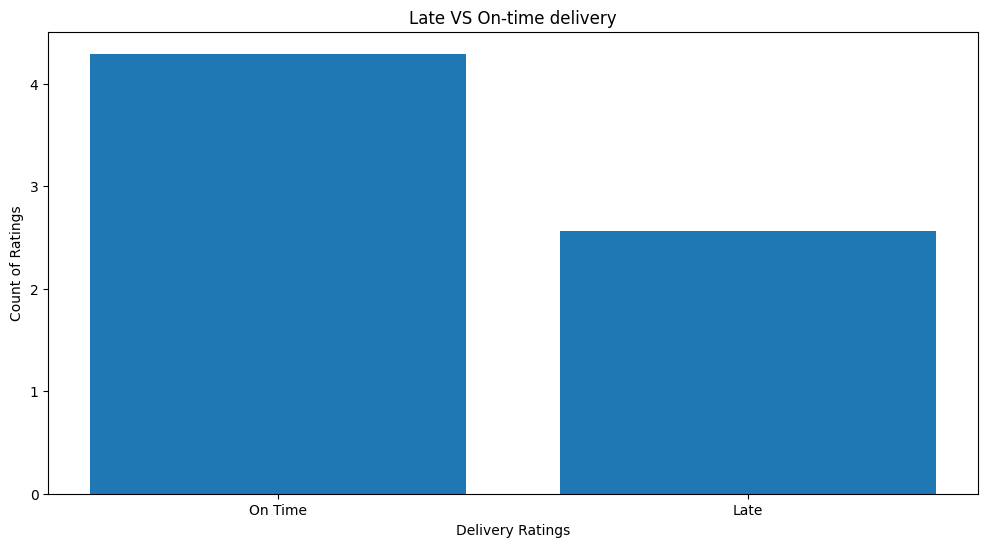

In [106]:
plt.figure(figsize=(12,6))
plt.bar(delivery_rating.index,delivery_rating.values)
plt.xticks([0, 1], ['On Time', 'Late'])
plt.title('Late VS On-time delivery')
plt.xlabel('Delivery Ratings')
plt.ylabel('Count of Ratings')
plt.savefig('late_vs_ontime_reviews', bbox_inches='tight', dpi=150)
plt.show()

In [97]:
category_revenue = result.groupby('product_category_name_english')['price'].sum().nlargest(10)
category_revenue

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

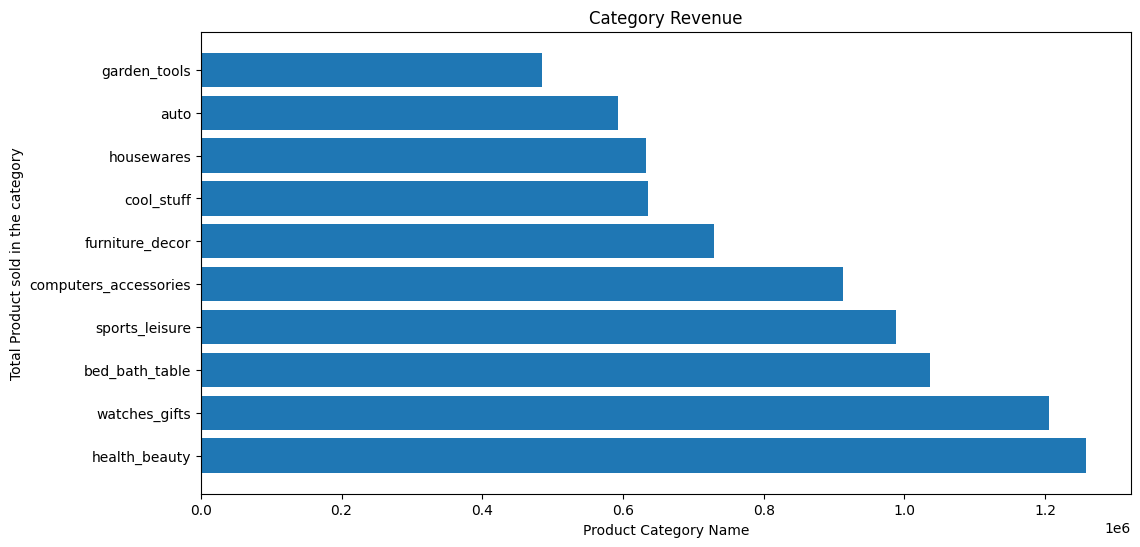

In [107]:
plt.figure(figsize=(12,6))
plt.barh(category_revenue.index,category_revenue.values)
plt.xlabel('Product Category Name')
plt.ylabel('Total Product sold in the category')
plt.title('Category Revenue')
plt.savefig('category_revenue.png', bbox_inches='tight', dpi=150)
plt.show()

In [102]:
seller_growth = result.groupby(['year','month'])['seller_id'].nunique().reset_index()
seller_growth['date'] = pd.to_datetime(seller_growth[['year','month']].assign(day=1))

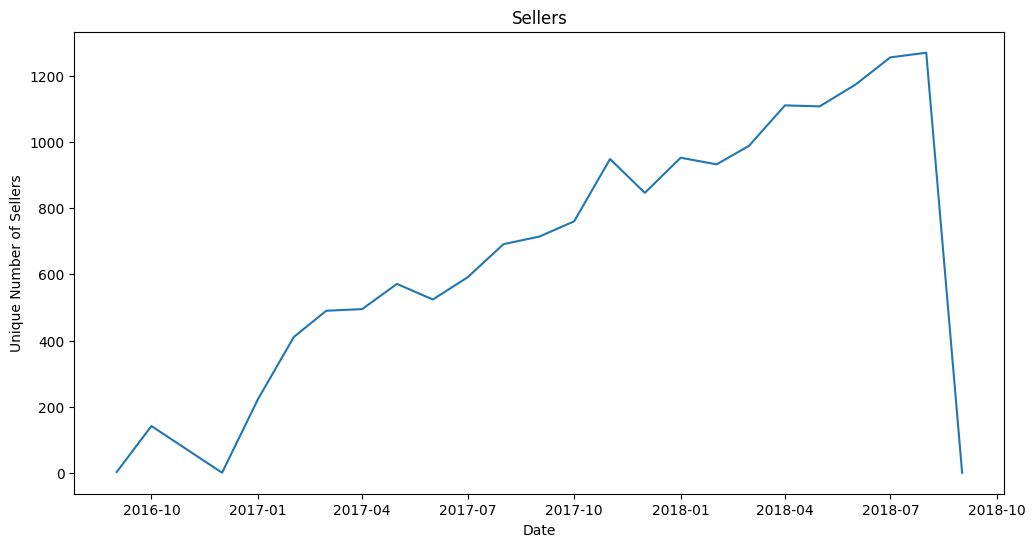

In [108]:
plt.figure(figsize=(12,6))
plt.plot(seller_growth['date'],seller_growth['seller_id'])
plt.title('Sellers')
plt.xlabel('Date')
plt.ylabel('Unique Number of Sellers')
plt.savefig('seller_growth.png', bbox_inches='tight', dpi=150)
plt.show()